In [1]:
# Import the libraries we need

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
import os

print(os.listdir())

['.vscode', 'customer_segmentation.ipynb', 'Mall_Customers.xls']


In [5]:
# Check the first few bytes of the file

with open("Mall_Customers.xls", "rb") as file:
    print(file.read(20))

b'CustomerID,Gender,Ag'


In [7]:
# Load the dataset

df = pd.read_csv("Mall_Customers.xls")

# Show the first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# Display basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [10]:
# Check if there are any missing values

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
# Convert Male and Female into numbers

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

# Display the first 5 rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [13]:
# Remove CustomerID because it is only an ID

X = df.drop("CustomerID", axis=1)

# Display the first 5 rows

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [14]:
# Scale the data before applying K-Means

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [ 1.12815215 -1.28103541 -1.73899919  1.19570407]
 [-0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [-0.88640526 -1.13750203 -1.70082976  1.04041783]
 [-0.88640526 -0.56336851 -1.66266033 -0.39597992]]


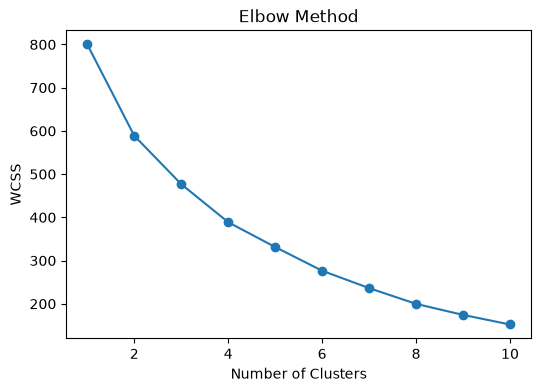

In [15]:
# Find the best number of clusters using the Elbow Method

wcss = []

# Try cluster values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
# Create the K-Means model with 5 clusters

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Train the model

clusters = kmeans.fit_predict(X_scaled)

In [18]:
# Add the cluster number to the dataset

df["Cluster"] = clusters

# Display the first 5 rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


In [19]:
# Reduce the data to 2 dimensions for visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)

Shape after PCA: (200, 2)


## PCA Result

The first two principal components explain approximately 59.9% of the total variance in the dataset. This means the two-dimensional PCA visualization captures a good portion of the original information, making it useful for visualizing the customer segments.

In [20]:
# Display the variance explained by the two principal components

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")

print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.33690046 0.26230645]

Total Explained Variance:
0.5992069019819846


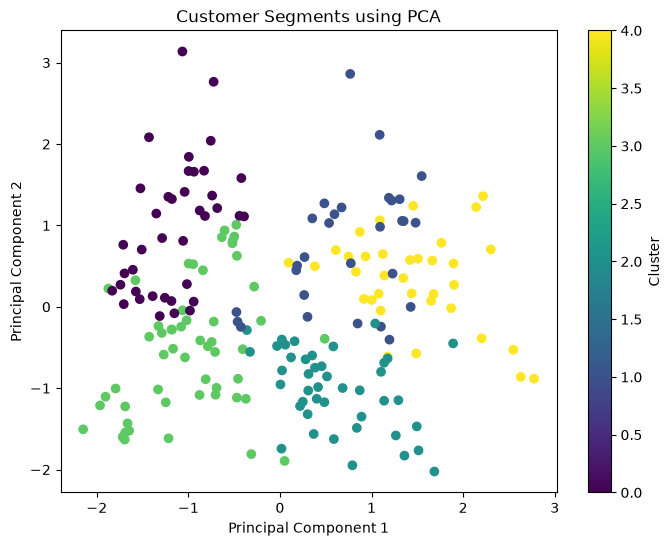

In [21]:
# Plot the customer clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [22]:
# Calculate the average values for each cluster

cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.461538,32.692308,86.538462,82.128205
1,165.482759,0.448276,36.482759,89.517241,18.000000
2,73.651163,0.000000,49.813953,49.232558,40.069767
3,52.814815,0.407407,24.907407,39.722222,61.203704
4,84.685714,1.000000,55.714286,53.685714,36.771429


In [27]:
# View the average values for each customer segment

segment_summary = df.groupby("Customer Segment").mean(numeric_only=True)

segment_summary

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
Customer Segment,,,,,,
High Income - High Spending,162.000000,0.461538,32.692308,86.538462,82.128205,0.0
High Income - Low Spending,165.482759,0.448276,36.482759,89.517241,18.000000,1.0
Middle Income - Low Spending,73.651163,0.000000,49.813953,49.232558,40.069767,2.0
Older Moderate Income - Low Spending,84.685714,1.000000,55.714286,53.685714,36.771429,4.0
Young Moderate Income - High Spending,52.814815,0.407407,24.907407,39.722222,61.203704,3.0


In [23]:
# Give each cluster a meaningful business name

cluster_names = {
    0: "High Income - High Spending",
    1: "High Income - Low Spending",
    2: "Middle Income - Low Spending",
    3: "Young Moderate Income - High Spending",
    4: "Older Moderate Income - Low Spending"
}

# Create a new column with the cluster names

df["Customer Segment"] = df["Cluster"].map(cluster_names)

# Display the first 10 rows

df[["CustomerID", "Customer Segment"]].head(10)

,CustomerID,Customer Segment
0,1,Young Moderate Income - High Spending
1,2,Young Moderate Income - High Spending
2,3,Young Moderate Income - High Spending
3,4,Young Moderate Income - High Spending
4,5,Young Moderate Income - High Spending
5,6,Young Moderate Income - High Spending
6,7,Middle Income - Low Spending
7,8,Young Moderate Income - High Spending
8,9,Older Moderate Income - Low Spending
9,10,Young Moderate Income - High Spending


In [24]:
# Count the number of customers in each segment

df["Customer Segment"].value_counts()

Customer Segment
Young Moderate Income - High Spending    54
Middle Income - Low Spending             43
High Income - High Spending              39
Older Moderate Income - Low Spending     35
High Income - Low Spending               29
Name: count, dtype: int64

## Business Insights

1. The "Young Moderate Income - High Spending" segment is the largest customer group with 54 customers. These customers are young, have moderate incomes, but spend more than other moderate-income groups.

2. The "High Income - High Spending" segment contains 39 customers. Although this is not the largest group, these customers have both high annual income and high spending scores, making them the most valuable customers.

3. The "High Income - Low Spending" segment has the highest average annual income but one of the lowest spending scores. This suggests that these customers have the ability to spend more but currently purchase less.

4. The "Middle Income - Low Spending" segment has 43 customers. They have average income and relatively low spending scores, indicating more careful spending habits.

5. The "Older Moderate Income - Low Spending" segment consists of older customers with moderate income and low spending scores. This group may prefer practical purchases instead of luxury products.

## Recommendations

1. Reward the High Income - High Spending customers with VIP memberships, exclusive offers, and loyalty rewards to encourage repeat purchases.

2. Provide personalized discounts and targeted marketing campaigns to High Income - Low Spending customers to increase their spending.

3. Offer affordable promotions and loyalty programs to Middle Income - Low Spending customers to encourage more frequent purchases.

4. Promote new products, seasonal offers, and trendy items to the Young Moderate Income - High Spending segment, as they already have high spending behavior.

5. Advertise practical, value-for-money products and special discounts to the Older Moderate Income - Low Spending segment to better match their shopping preferences.